In [52]:
import pickle
from glob import glob
import os.path as op
import pandas as pd

from functools import reduce
from operator import getitem

import matplotlib.pyplot as plt
from scipy import stats
import xcp_d
import seaborn as sns
import numpy as np

In [53]:
xcpd_path = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/connectivity-matrices/xcpd/lassoBIC_ses'
xcpd_pkls = glob(op.join(op.join(xcpd_path, 'sub-*', '*.pkl')))[:100]  

In [54]:
sub_list = [] 

In [55]:
for file in xcpd_pkls: 
    sub_list.append(op.basename(file).split('_')[0]) 


In [56]:
node_list = [f"node_{ii}" for ii in range(0,100)] 

In [57]:
fold_list = [f"fold_{ii}" for ii in range(0,2)] 

In [58]:
iterables = [fold_list, node_list]

In [59]:
def extract_r2(file, r2_df): 
    sub = op.basename(file).split('_')[0]

    with open(file, 'rb') as l:
        result_dict = pickle.load(l)

    for ii in range(0,2): 
        for jj in range(0,100):
            r2_df.loc[(f'fold_{ii}', f'node_{jj}'), sub] = reduce(getitem, 
                                                                  (f'fold_{ii}', f'node_{jj}', 'test_r2'), 
                                                                  result_dict) 
    return r2_df

In [60]:
index = pd.MultiIndex.from_product(iterables, names=["fold", "node"])
temp_df = pd.DataFrame(index=index, columns=sub_list, dtype=float)
r2_df = temp_df
for file in xcpd_pkls: 
    r2_df = extract_r2(file, r2_df) 
r2_df.to_csv('xcpd_r2_2025-10-24_r2.csv') 

In [61]:
np.mean(r2_df) 

np.float64(0.2697949962079525)

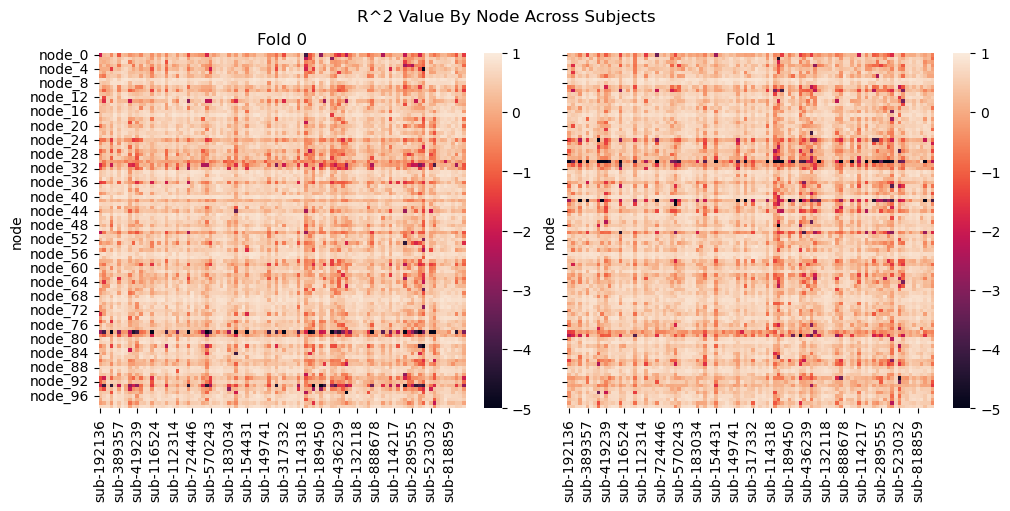

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharex=True, sharey=True, layout="constrained") 
sns.heatmap(ax=ax[0], data=r2_df.loc['fold_0'], vmax=1, vmin=-5)
ax[0].set_title("ses 1") 
ax[1].set_title("ses 2") 
# ax[2].set_title("Fold 2") 
# ax[3].set_title("Fold 3") 
# ax[4].set_title("Fold 4") 

sns.heatmap(ax=ax[1], data=r2_df.loc['fold_1'], vmax=1, vmin=-5)
# sns.heatmap(ax=ax[2], data=r2_df.loc['fold_2'], vmax=1, vmin=-5)
# sns.heatmap(ax=ax[3], data=r2_df.loc['fold_3'], vmax=1, vmin=-5)
# sns.heatmap(ax=ax[4], data=r2_df.loc['fold_4'], vmax=1, vmin=-5)

# ax[4].set_title("Fold 4") 
# ax[0].set_xlabel("Subject") 
fig.suptitle("R^2 Value By Node Across Subjects") 
plt.savefig('r2_byfold.png') 

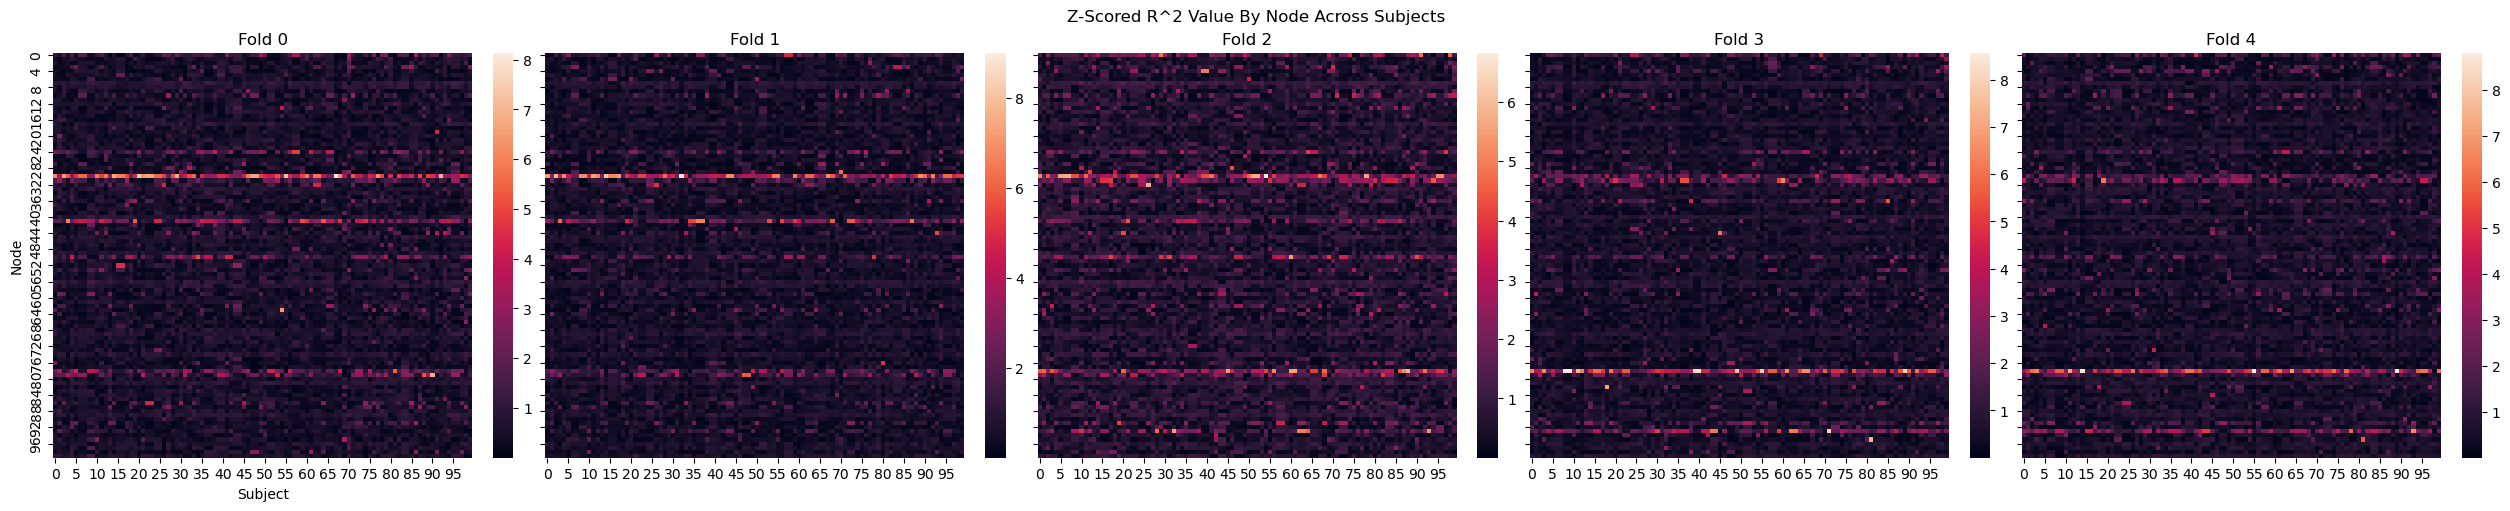

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(25, 5), sharex=True, sharey=True, layout="constrained") 
sns.heatmap(ax=ax[0], data=np.abs(stats.zscore(r2_df.loc['fold_0'])))


sns.heatmap(ax=ax[1], data=np.abs(stats.zscore(r2_df.loc['fold_1'])))
sns.heatmap(ax=ax[2], data=np.abs(stats.zscore(r2_df.loc['fold_2'])))
sns.heatmap(ax=ax[3], data=np.abs(stats.zscore(r2_df.loc['fold_3'])))
sns.heatmap(ax=ax[4], data=np.abs(stats.zscore(r2_df.loc['fold_4'])))
ax[0].set_title("Fold 0") 
ax[1].set_title("Fold 1") 
ax[2].set_title("Fold 2") 
ax[3].set_title("Fold 3") 
ax[4].set_title("Fold 4") 

ax[0].set_xlabel("Subject") 
ax[0].set_ylabel("Node") 

fig.suptitle("Z-Scored R^2 Value By Node Across Subjects") 
plt.savefig('r2_byfold.png') 

In [12]:
outliers = [] 

In [13]:
mean_df = r2_df.loc[f'fold_0'].mean(axis=1)

mean_df[np.abs(stats.zscore(mean_df) ) > 2]
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index) 


In [14]:
mean_df = r2_df.loc[f'fold_1'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index)

In [15]:
mean_df = r2_df.loc[f'fold_2'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index)

In [16]:
mean_df = r2_df.loc[f'fold_3'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index) 

In [17]:
mean_df = r2_df.loc[f'fold_4'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index)

In [18]:
#datalad clone atlaspack.git
#datalad get 4156.dseg

In [19]:
 from collections import Counter

In [20]:
Counter(outliers)

Counter({'node_78': 5,
         'node_30': 4,
         'node_31': 3,
         'node_41': 2,
         'node_50': 2,
         'node_79': 2,
         'node_93': 2,
         'node_0': 1})

In [21]:
atlas_file = '/global/u1/m/mphagen/AtlasPack/atlas-4S156Parcels_dseg.tsv' 

In [22]:
atlas_df = pd.read_csv(atlas_file, sep='\t')

In [23]:
atlas_df.iloc[[30, 31, 41, 50, 78, 79, 93]][['label', 'label_7network']]

,label,label_7network
30,LH_Limbic_OFC_1,7Networks_LH_Limbic_OFC_1
31,LH_Limbic_TempPole_1,7Networks_LH_Limbic_TempPole_1
41,LH_Default_PFC_1,7Networks_LH_Default_PFC_1
50,RH_Vis_1,7Networks_RH_Vis_1
78,RH_Limbic_OFC_1,7Networks_RH_Limbic_OFC_1
79,RH_Limbic_TempPole_1,7Networks_RH_Limbic_TempPole_1
93,RH_Default_PFCv_1,7Networks_RH_Default_PFCv_1


In [32]:
import nibabel as nb

In [40]:
ts_files = glob('/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/timeseries/xcpd/sub-102109/*rest*ses-*.nii')

In [41]:
cifti_1 = nb.load(ts_files[0])
cifti_data_1 = cifti_1.get_fdata(dtype=np.float32)

In [42]:
cifti_2 = nb.load(ts_files[1])
cifti_data_2 = cifti_2.get_fdata(dtype=np.float32)

In [47]:
cifti_data = np.append(cifti_data_1, cifti_data_2, axis=0) 

In [48]:
cifti_data.shape

(4800, 156)

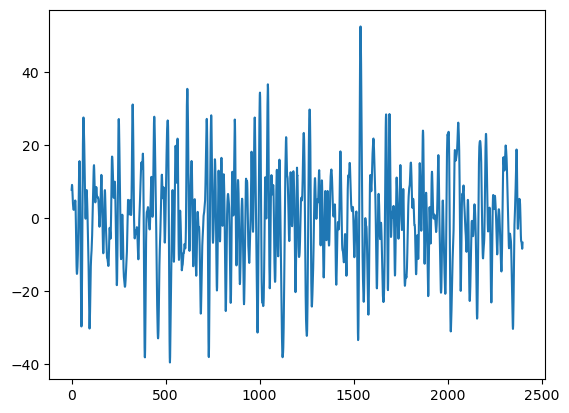

In [51]:
plt.plot(cifti_data[:2400, 50]) 

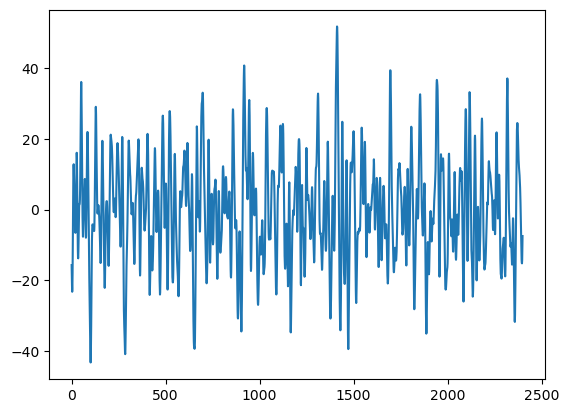

In [50]:
plt.plot(cifti_data[2400:, 50]) 

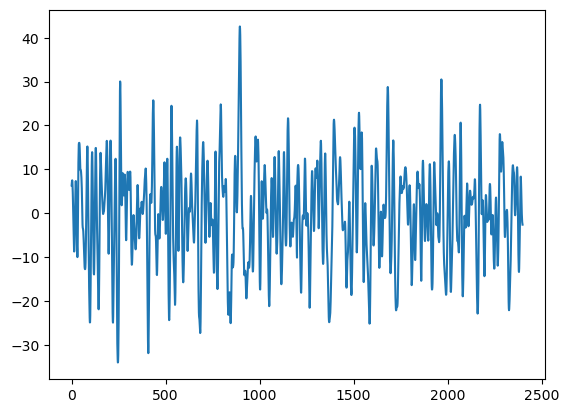

In [30]:
plt.plot(cifti_data[:, 24]) 

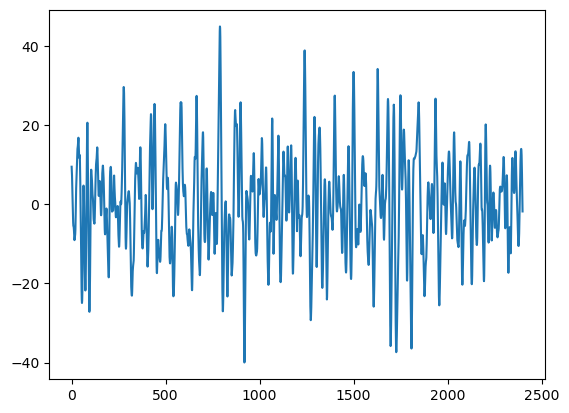

In [31]:
plt.plot(cifti_data[:, 76]) 

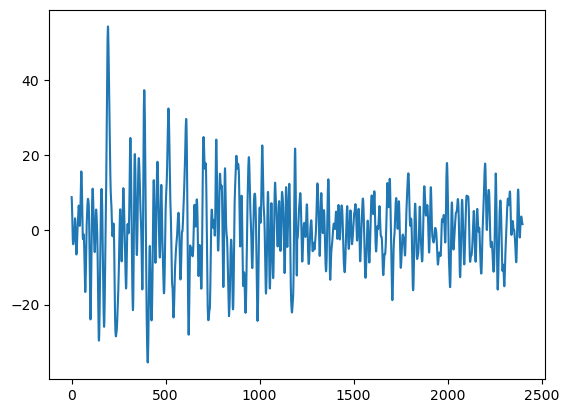

In [32]:
plt.plot(cifti_data[:, 30]) 

In [33]:
with open('all_variables.pkl', 'wb') as f:
    pickle.dump(r2_df, f)